In [22]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
from datetime import datetime
import seaborn as sns


os.environ['TZ'] = 'Europe/Berlin'
import time
time.tzset()
def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

In [74]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
adata = sc.read_h5ad(f"{BASE}/data/03_HIHAtlas/HIHAtlas_ds_TICAannot_tmin2.h5ad")
adata_tmin0 = sc.read_h5ad(f"{BASE}/data/03_HIHAtlas/HIHAtlas_ds_TICAannot_tmin0.h5ad")
adata_tmin1 = sc.read_h5ad(f"{BASE}/data/03_HIHAtlas/HIHAtlas_ds_TICAannot_tmin1.h5ad")

In [11]:
checkpoint(adata_tmin0.obs['decoupler_level1_celltype'].values)
checkpoint(adata_tmin1.obs['decoupler_level1_celltype'].values)

[2026-09-04 14:06:49] ['pDC', 'pDC', 'pDC', 'pDC', 'pDC', ..., 'Plasma B cells', 'B cells', 'B cells', 'B cells', 'pDC']
Length: 129435
Categories (23, object): ['B cells', 'B cells proliferative', 'CD4 effector memory', 'CD4 naive-memory', ..., 'TAMs proinflammatory', 'cDC', 'mDC', 'pDC']
[2026-09-04 14:06:49] ['pDC', 'pDC', 'pDC', 'pDC', 'pDC', ..., 'Plasma B cells', 'B cells', 'B cells', 'B cells', 'pDC']
Length: 129435
Categories (23, object): ['B cells', 'B cells proliferative', 'CD4 effector memory', 'CD4 naive-memory', ..., 'TAMs proinflammatory', 'cDC', 'mDC', 'pDC']


In [19]:
adata.var_names.isin(["C1QB", "APOE", "C1QA", "C1QC", "APOC1", "SEPP1", "SPP1", "CD163"]).sum()

np.int64(7)

In [26]:
ct = pd.crosstab(
    adata.obs["decoupler_level1_celltype"],   # rows
    adata_tmin1.obs["decoupler_level1_celltype"],   # columns                  
)
checkpoint(f"Cross-tabulation of TICA and HIHA labels:\n{ct}")

[2026-09-04 14:23:46] Cross-tabulation of TICA and HIHA labels:
decoupler_level1_celltype  B cells  B cells proliferative  \
decoupler_level1_celltype                                   
B cells                      12006                      0   
B cells proliferative            0                   2437   
CD4 effector memory              0                      0   
CD4 recently activated           0                      0   
CD4 transitional memory          0                      0   
CD8 cytotoxic                    0                      0   
CD8 effector memory              0                      0   
CD8 pre-exhausted                0                      0   
CD8 terminally exhausted         0                      0   
Macro. and mono. prolif.         0                      0   
Monocytes                        0                      0   
NK                               0                      0   
Plasma B cells                   0                      0   
T cells naive        

In [27]:
ct_norm_row = ct.div(ct.sum(axis=1), axis=0)
adata_tmin0.obs["decoupler_level1_celltype"].value_counts().index.sort_values().tolist()

['B cells',
 'B cells proliferative',
 'CD4 effector memory',
 'CD4 naive-memory',
 'CD4 recently activated',
 'CD4 transitional memory',
 'CD8 cytotoxic',
 'CD8 effector memory',
 'CD8 pre-exhausted',
 'CD8 terminally exhausted',
 'Macro. and mono. prolif.',
 'Monocytes',
 'NK',
 'Plasma B cells',
 'T cells naive',
 'T cells proliferative',
 'T cells regulatory',
 'T helper cells',
 'TAMs C1QC',
 'TAMs proinflammatory',
 'cDC',
 'mDC',
 'pDC']

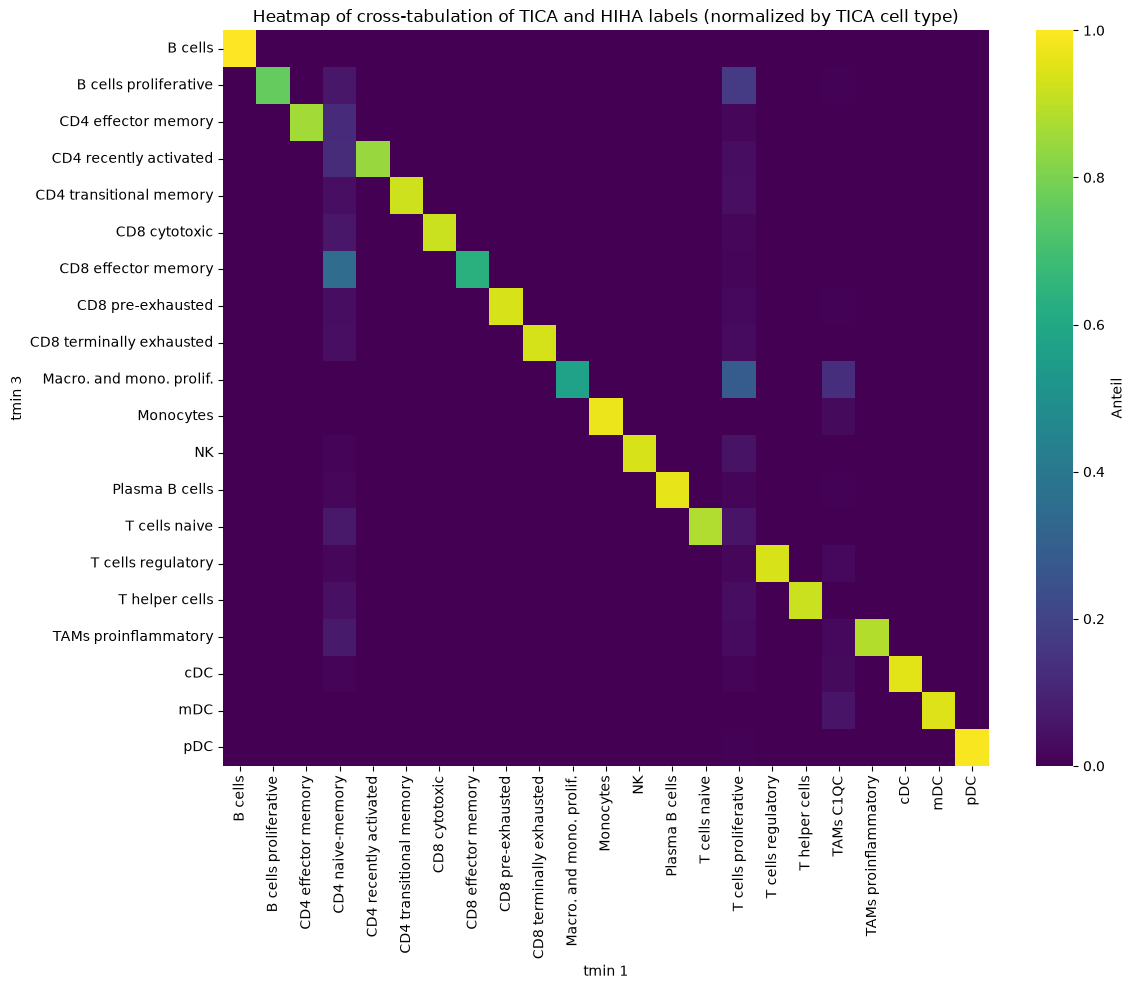

In [30]:
# out_pdf = os.path.join(OUT_DIR, "09_10_HIHA_TICA_annotation_heatmap_1.pdf")
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(ct_norm_row, annot=False, fmt=".2f", cmap="viridis", ax=ax, cbar_kws={"label": "Anteil"}, vmin = 0, vmax=1)
ax.set_xlabel("tmin 1")
ax.set_ylabel("tmin 3")
ax.set_title("Heatmap of cross-tabulation of TICA and HIHA labels (normalized by TICA cell type)")
plt.tight_layout()
# plt.savefig(out_pdf, bbox_inches="tight", dpi=300)

In [33]:
adata.obs["decoupler_level1_score"]

barcodes
74fc381648b611eabab7c676ab45cfca    10.761700
5cfdece648b111ea8fbed2ddb8e0a14a     9.193367
6cfb85c848b511ea87c666a4322bd84a     4.519198
54b6da1e495311ea86cade558b2f8879     9.326918
54cdf6ae495311ea86cade558b2f8879     7.915801
                                      ...    
b9412c54bfcd11ebbdb0527e5f17f167     4.976003
d2b44036bfdc11eb9ba92275cea06a7e     4.863490
7e40967ee40511eb8b4326d57b156660     2.807208
dbb7662abfde11eb9e6d96f9d8b57902     5.457685
df1f9ea448cf11eaacaa42cd98cbd24e     4.628017
Name: decoupler_level1_score, Length: 129435, dtype: float32

In [41]:
tmin1_scores = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_02_decoupler_gpu_celltype_annotation_tmin1.csv", index_col=0)
t_prolif = tmin1_scores.loc[tmin1_scores["decoupler_level1_celltype"] == "T cells proliferative", :]
t_prolif

,decoupler_level1_celltype,decoupler_level1_score,decoupler_level2_celltype,decoupler_level2_score
barcodes,,,,
9103c3904dfe11ec9cd7da9b7cf4e69b,T cells proliferative,7.328375,DC2 CD1C+,5.600862
72ce9bea60b111eda69772bc2278a4b2,T cells proliferative,7.598945,T cells proliferative,10.204782
27ad6f0aca0411ebbb136a0d2fbd39b2,T cells proliferative,3.372938,DC4 CD1C-,4.145574
10de333ae3ff11eb9f4d12c99271e885,T cells proliferative,3.586438,DC4 CD1C-,6.490689
bbe55bdcca0f11eba0c402013b74b858,T cells proliferative,3.267089,DC4 CD1C-,5.768268
...,...,...,...,...
443507cc50ba11ec9ccf362b40e6d4a7,T cells proliferative,0.427395,B cells memory,-0.239779
d41efe3c50a211ecb05e625212408fd6,T cells proliferative,0.407176,B cells memory,-0.261028
d7bb8124872a11eb9956d6a6a5ac404c,T cells proliferative,7.335346,B cells proliferative,8.236353


In [72]:
tmin3_scores = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_02_decoupler_gpu_celltype_annotation_tmin3.csv", index_col=0)
t_prolif_barcodes = t_prolif.index
tmin3_subset = tmin3_scores.loc[t_prolif_barcodes]
tmin3_subset["decoupler_level1_celltype"].value_counts()

decoupler_level1_celltype
Macro. and mono. prolif.    2036
T cells naive                611
B cells proliferative        554
NK                           512
CD4 transitional memory      249
T cells regulatory           206
T helper cells               132
CD4 effector memory          129
CD8 cytotoxic                125
CD4 recently activated       120
CD8 effector memory           99
CD8 terminally exhausted      82
CD8 pre-exhausted             81
Plasma B cells                74
TAMs proinflammatory          60
pDC                           54
cDC                           23
B cells                        6
Monocytes                      5
mDC                            2
Name: count, dtype: int64

In [64]:
score_diff = t_prolif["decoupler_level1_score"] - tmin3_subset["decoupler_level1_score"]
score_diff

barcodes
9103c3904dfe11ec9cd7da9b7cf4e69b    0.691218
72ce9bea60b111eda69772bc2278a4b2    1.446700
27ad6f0aca0411ebbb136a0d2fbd39b2    0.745024
10de333ae3ff11eb9f4d12c99271e885    0.517294
bbe55bdcca0f11eba0c402013b74b858    0.829575
                                      ...   
443507cc50ba11ec9ccf362b40e6d4a7    0.342981
d41efe3c50a211ecb05e625212408fd6    0.329800
d7bb8124872a11eb9956d6a6a5ac404c    3.879849
4e61b5543f6f11eb958d9a3b616bee06    0.906858
b93d4d624dff11ecb1a91aa839721c60    0.861328
Name: decoupler_level1_score, Length: 5160, dtype: float64

In [73]:
tmin3_scores.loc[score_diff.index[score_diff <= 0.5], "decoupler_level1_celltype"].value_counts()

decoupler_level1_celltype
T cells naive               263
B cells proliferative       144
CD4 transitional memory      99
Macro. and mono. prolif.     63
T cells regulatory           61
T helper cells               55
CD4 effector memory          54
NK                           52
CD4 recently activated       40
TAMs proinflammatory         37
CD8 effector memory          34
CD8 pre-exhausted            29
pDC                          29
CD8 cytotoxic                24
Plasma B cells               12
cDC                          10
CD8 terminally exhausted      9
B cells                       4
Monocytes                     2
mDC                           1
Name: count, dtype: int64

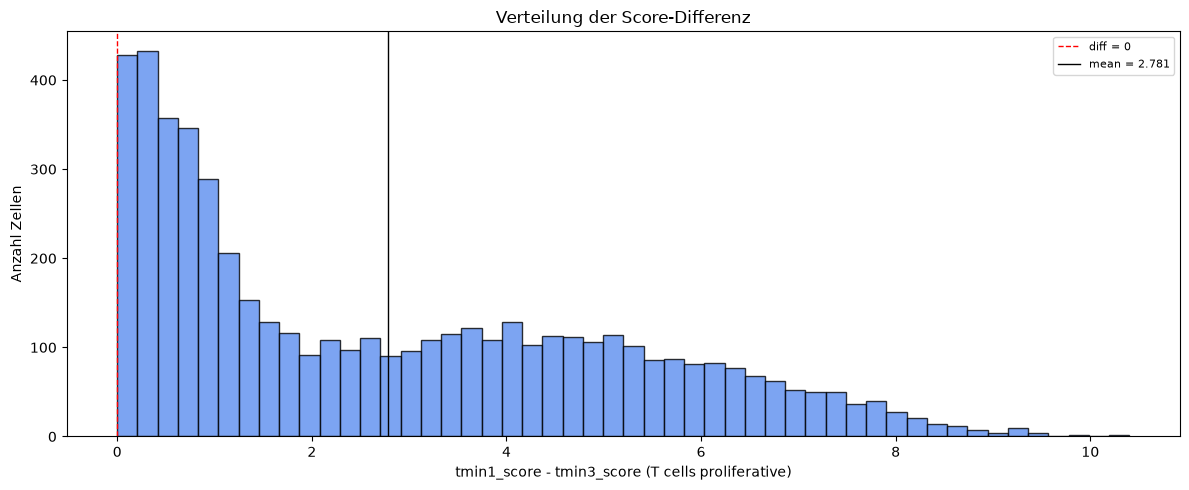

count    5160.000000
mean        2.780617
std         2.366631
min         0.000066
25%         0.663866
50%         2.144491
75%         4.618122
max        10.401423
Name: decoupler_level1_score, dtype: float64
n_positive (tmin1 > tmin3): 5160 / 5160
n_negative (tmin1 < tmin3): 0 / 5160


In [62]:
fig, ax = plt.subplots(1,figsize=(12, 5))

# ── Histogramm: Verteilungsform der Score-Differenz
ax.hist(score_diff, bins=50, color="#5b8def", edgecolor="black", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1, label="diff = 0")
ax.axvline(score_diff.mean(), color="black", linestyle="-", linewidth=1,
                 label=f"mean = {score_diff.mean():.3f}")
ax.set_xlabel("tmin1_score - tmin3_score (T cells proliferative)")
ax.set_ylabel("Anzahl Zellen")
ax.set_title("Verteilung der Score-Differenz")
ax.legend(fontsize=8)


plt.tight_layout()
# plt.savefig("output/score_diff_tprolif.pdf", bbox_inches="tight", dpi=150)
plt.show()
plt.close()

print(score_diff.describe())
print(f"n_positive (tmin1 > tmin3): {(score_diff > 0).sum()} / {len(score_diff)}")
print(f"n_negative (tmin1 < tmin3): {(score_diff < 0).sum()} / {len(score_diff)}")

In [66]:
NET_LEVEL1_CSV = f"{BASE}/data/02_TICA/TICA_gene_markers_level1_table_s2.csv"
def load_net(path):
    df = pd.read_csv(path)
    net = df.rename(columns={"cell_type": "source", "gene": "target"})[["source", "target"]].copy()
    net["weight"] = 1.0  # unweighted
    return net
net_level1 = load_net(NET_LEVEL1_CSV)


In [67]:
genes_ct = net_level1.loc[net_level1["source"] == "T cells proliferative", "target"]
present = genes_ct[genes_ct.isin(adata.var_names)]
print(f"Total definiert: {len(genes_ct)}, in adata vorhanden: {len(present)}")
print(list(present))

Total definiert: 3, in adata vorhanden: 3
['STMN1', 'MKI67', 'CDK1']


In [69]:
NEW_LABEL = "T cell proliferative"
col = "decoupler_level1_celltype"

# ── sicherstellen, dass die Spalte categorical ist und die neue Kategorie
# vor der Zuweisung existiert (sonst: ValueError bei categorical dtype)
if not isinstance(adata.obs[col].dtype, pd.CategoricalDtype):
    adata.obs[col] = adata.obs[col].astype("category")

if NEW_LABEL not in adata.obs[col].cat.categories:
    adata.obs[col] = adata.obs[col].cat.add_categories([NEW_LABEL])

# ── nur Barcodes, die tatsächlich in adata vorhanden sind, verwenden
# (Suffix-Mismatch-Schutz wie in den vorherigen Skripten)
common = adata.obs_names.intersection(t_prolif_barcodes)
n_dropped = len(t_prolif_barcodes) - len(common)
print(f"Common barcodes: {len(common)} / {len(t_prolif_barcodes)} (dropping {n_dropped} not found in adata)")

if len(common) == 0:
    raise ValueError("Keine der t_prolif_barcodes in adata.obs_names gefunden — Barcode-Format prüfen.")

adata.obs.loc[common, col] = NEW_LABEL

print(adata.obs[col].value_counts().to_string())

Common barcodes: 5160 / 5160 (dropping 0 not found in adata)
decoupler_level1_celltype
B cells                     12042
T cells regulatory          11830
T cells naive               11090
Monocytes                   10827
NK                          10137
pDC                          8760
CD8 effector memory          6894
CD8 cytotoxic                6761
CD4 effector memory          6605
CD4 transitional memory      6346
T cell proliferative         5160
Plasma B cells               5030
Macro. and mono. prolif.     5010
T helper cells               3903
CD8 pre-exhausted            3569
CD4 recently activated       3564
CD8 terminally exhausted     2757
B cells proliferative        2644
cDC                          2376
TAMs proinflammatory         2101
mDC                          2029


In [71]:
OUT_PATH = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/03_HIHAtlas/HIHAtlas_ds_TICA_adj.h5ad"
import anndata
anndata.settings.allow_write_nullable_strings = True

adata.write(OUT_PATH)
checkpoint(f"Updated adata written to {OUT_PATH}")

[2026-09-04 15:20:04] Updated adata written to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/03_HIHAtlas/HIHAtlas_ds_TICA_adj.h5ad
